# **PCA**

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score

In [2]:
#loading mnist
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


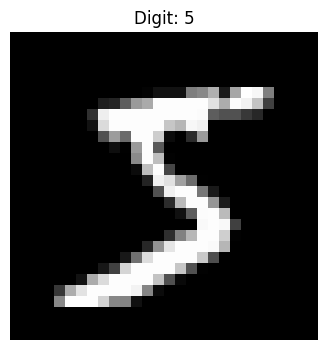

In [3]:
#inspecting one image:
plt.figure(figsize=(4, 4))

plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Digit: {y[0]}")
plt.axis('off')

plt.show()

In [4]:
#creating train/test sets:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (56000, 784)
Testing data: (14000, 784)


In [5]:
#scaling data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(56000, 784)


In [6]:
#performing PCA(tranforming 784 features to 2D)
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

print("Original dimensions:", X_train_scaled.shape[1])
print("Reduced dimensions:", X_train_pca_2d.shape[1])

Original dimensions: 784
Reduced dimensions: 2


In [7]:
#checking variance explained
print("Explained variance ratio:")
print(pca_2d.explained_variance_ratio_)

print("Total variance explained:",
      pca_2d.explained_variance_ratio_.sum())

Explained variance ratio:
[0.05643647 0.04044649]
Total variance explained: 0.09688296079609157


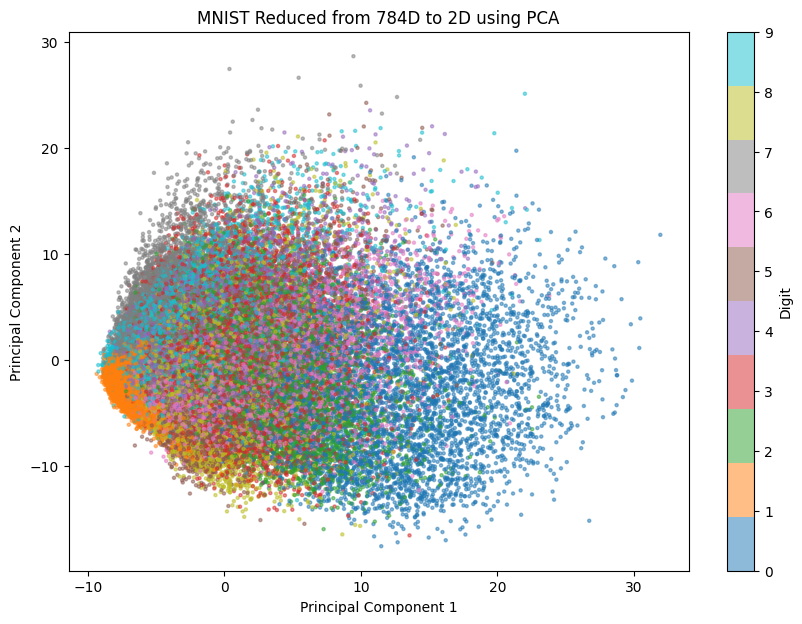

In [8]:
#plotting PCA 2D
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap='tab10',
    s=5,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Reduced from 784D to 2D using PCA")

plt.colorbar(scatter, label="Digit")

plt.show()

In [9]:
#now reducing to 50d
pca_50 = PCA(n_components=50)

X_train_pca_50 = pca_50.fit_transform(X_train_scaled)
X_test_pca_50 = pca_50.transform(X_test_scaled)

print("Original dimensions:", X_train_scaled.shape[1])
print("Reduced dimensions:", X_train_pca_50.shape[1])

Original dimensions: 784
Reduced dimensions: 50


In [10]:
total_variance_50 = pca_50.explained_variance_ratio_.sum()

print("Variance explained by 50 components:",
      total_variance_50)

Variance explained by 50 components: 0.5508231766908426


In [11]:
#train a classifier using PCA-50
clf_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf_pca.fit(X_train_pca_50, y_train)

y_pred_pca = clf_pca.predict(X_test_pca_50)

accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy using PCA (50 dimensions):", accuracy_pca)

Accuracy using PCA (50 dimensions): 0.901


In [12]:
#training on original 784 dimensions
clf_full = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf_full.fit(X_train_scaled, y_train)

y_pred_full = clf_full.predict(X_test_scaled)

accuracy_full = accuracy_score(y_test, y_pred_full)

print("Accuracy using original 784 dimensions:", accuracy_full)

Accuracy using original 784 dimensions: 0.9164285714285715


In [14]:
#using a subset of data for t-SNE
X_tsne = X_train_scaled[:5000]
y_tsne = y_train[:5000]

print(X_tsne.shape)

(5000, 784)


In [15]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_train_tsne = tsne.fit_transform(X_tsne)

print("t-SNE shape:", X_train_tsne.shape)

t-SNE shape: (5000, 2)


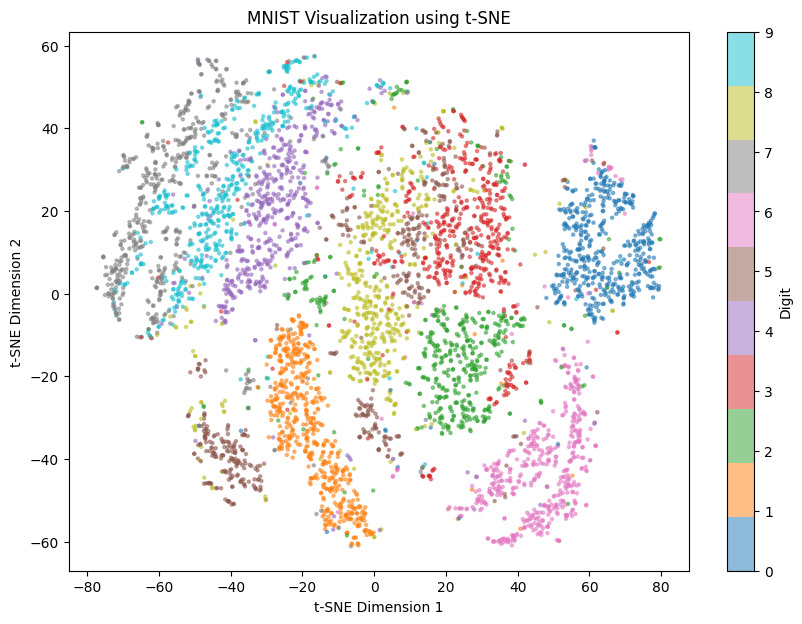

In [16]:
#plotting t-SNE
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_train_tsne[:, 0],
    X_train_tsne[:, 1],
    c=y_tsne,
    cmap='tab10',
    s=5,
    alpha=0.5
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("MNIST Visualization using t-SNE")

plt.colorbar(scatter, label="Digit")

plt.show()

In [17]:
#final comparison
results = pd.DataFrame({
    "Method": [
        "Original MNIST",
        "PCA (50 dimensions)"
    ],
    "Dimensions": [
        784,
        50
    ],
    "Accuracy": [
        accuracy_full,
        accuracy_pca
    ]
})

results

,Method,Dimensions,Accuracy
0,Original MNIST,784,0.916429
1,PCA (50 dimensions),50,0.901000


# **Final summary:**

PCA successfully reduced the MNIST dataset from 784 dimensions to 50 dimensions, while retaining 55.08% of the total variance. The 2D PCA visualization shows significant overlap between digit classes, whereas the t-SNE visualization produces much clearer and more distinct clusters, making it more effective for visualizing class separation. For classification, the original 784-dimensional data achieved 91.64% accuracy, while PCA with only 50 dimensions achieved 90.10% accuracy. Thus, PCA reduced the number of features by over 93% with only about a 1.54 percentage-point drop in accuracy, demonstrating that PCA can provide substantial dimensionality reduction while preserving most of the information useful for classification.